# `PROC CAUSALMED` による金融リテラシープログラムのローンデフォルトへの効果の分解


## エグゼクティブサマリー

ある小売銀行は、一部の借り手を **金融リテラシープログラム** に組み入れており、加入した借り手のデフォルトが少ない *理由* を知りたいと考えています。加入はデフォルトを **直接的** に低下させるのか、それとも測定可能な行動 — 顧客が収入のどれだけを貯蓄するか — を変えることで **間接的** に作用するのでしょうか。本ノートブックでは **PROC CAUSALMED** を用いて、プログラムの 12 か月デフォルトに対する総効果を、**自然直接効果** と、各借り手の **貯蓄率** を経由する **自然間接効果** に分解し、信用スコア・収入・年齢を調整します。

**100 人の借り手** からなるシミュレーションコホートでは、プログラムはモデル化されたデフォルト確率を **0.208** 低下させます(リスク差スケールでの総効果)。この分解は、そのうち **0.176(84.7%)** を貯蓄率上昇を通じた *間接* 経路に、わずか **0.032(15.3%)** を *直接* 経路に帰属させます。実務上の要点は、このプログラムは **主に貯蓄行動を改善することで** 借り手を保護しているということであり、家計管理の習慣を強化することにこそレバレッジがあります。

## データソース

| データセット | 行数 | 説明 | 主な変数 |
|---------|------|-------------|---------------|
| `LoanProgram` | 合成された借り手 100 人 | 1 つの融資ポートフォリオを対象に、インラインで生成された小売銀行コホート。処置の割り当て・媒介変数・アウトカムは明示的な構造方程式からシミュレートされており、プロシジャが回収すべき真の媒介効果が存在します。 | `CustomerID`、`Branch`(4 水準)、`FinEdu`(0/1 金融教育への加入 = 処置)、`SavingsRate`(貯蓄率 = 連続媒介変数)、`Default`(0/1 12 か月ローンデフォルト = 二値アウトカム)、`CreditScore`、`Income`、`Age`(交絡因子) |

この環境はライセンスなしで実行されるため、DATA ステップは 100 観測に制限されています。コホートはその上限に合わせたサイズであり、本ノートブック内のすべての数値はこの 100 行から得られています。

## なぜ効果を分解するのか?

小売の貸し手は、延滞を減らすために信用商品と **金融リテラシープログラム** を組み合わせることが増えています。資本計画やプログラム設計にとって、加入がデフォルトを *低下させる* という事実だけを知るのでは不十分であり、リスク担当者は **メカニズム** を必要とします。

- 加入はデフォルトを *直接的* に低下させるのか(例えば、加入した借り手はより関与し続け、連絡が取りやすいなど)?
- それとも、測定可能な行動 — 顧客が収入のうち貯蓄する割合 — を変えることで *間接的* に作用し、それがショックに対する緩衝となるのか?

**因果媒介分析** は、処置の **総効果(TE)** を、**自然直接効果(NDE)** と、選ばれた媒介変数を経由する **自然間接効果(NIE)** に分割することで、この問いに答えます。ここでは以下のとおりです。

- **処置** `FinEdu` — 借り手が銀行の金融教育プログラムに加入したかどうか;
- **媒介変数** `SavingsRate` — 借り手の貯蓄率(収入に対する%)、すなわちプログラムが狙う行動;
- **アウトカム** `Default` — ローンが 12 か月以内にデフォルトしたかどうか(二値);
- **交絡因子** `CreditScore`、`Income`、`Age` — 加入・貯蓄・デフォルトに影響する処置前の特性。

`PROC CAUSALMED` で媒介モデルを当てはめ、`DECOMP` で直接効果/間接効果の分解を要求し、保護効果のうち貯蓄を通じて流れる割合を読み取ります。

In [1]:
データ LoanProgram;
   呼出 streaminit(20260531);
   長さ Branch $12;
   配列 branches[4] $12 _temporary_ ('North' 'South' 'East' 'West');
   繰返 CustomerID = 1 から 100;
      Branch = branches[1 + int(rand('uniform')*4)];

      /* 処置前の交絡因子（最初に生成） */
      CreditScore = round(620 + 70*rand('normal'), 1);
      もし CreditScore < 350 なら CreditScore = 350;
      もし CreditScore > 850 なら CreditScore = 850;
      Income = round(42000 + 14000*rand('normal'), 100);
      もし Income < 12000 なら Income = 12000;
      AGE = round(40 + 11*rand('normal'), 1);
      もし AGE < 21 なら AGE = 21;

      /* 処置：登録傾向は信用スコアと所得とともに上昇する
         （素朴な比較が見落とす交絡） */
      pTreat = 1 / (1 + EXP(-(0.0 + 0.005*(CreditScore-620)
                               + 0.00002*(Income-42000))));
      FinEdu = (rand('uniform') < pTreat);

      /* 媒介変数：貯蓄率。交絡で決まるベースラインに
         プログラム効果が上乗せされる */
      base_save = 9 + 0.025*(CreditScore-620) + 0.00010*(Income-42000)
                    + 0.04*(AGE-40);
      SavingsRate = base_save + 2.5*FinEdu + 2.0*rand('normal');
      もし SavingsRate < 0 なら SavingsRate = 0;

      /* 結果：債務不履行確率は登録（直接効果）と
         貯蓄率の上昇（間接効果）の両方で低下する */
      eta = 0.55 - 0.30*FinEdu - 0.022*(SavingsRate-12)
            - 0.0012*(CreditScore-620)
            - 0.0000040*(Income-42000)
            + 0.15*rand('normal');
      pDefault = eta;
      もし pDefault < 0.02 なら pDefault = 0.02;
      もし pDefault > 0.98 なら pDefault = 0.98;
      Default = (rand('uniform') < pDefault);
      出力;
   終了;
   保持 CustomerID Branch FinEdu SavingsRate Default
        CreditScore Income AGE;
実行;


NOTE: DATA LoanProgram


NOTE: Wrote LoanProgram (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## ステップ 2 — シミュレーションコホートを確認する

因果モデルを当てはめる前に、各加入群における平均貯蓄率とデフォルト率を確認します。これは *素朴な*(調整なしの)比較です。続く媒介分析はこれを超えて、その差を直接経路と媒介経路とに帰属させます。

In [2]:
処理 平均 データ=LoanProgram n mean std maxdec=3;
   分類 FinEdu;
   変数 SavingsRate Default CreditScore Income AGE;
   label FinEdu='金融教育' Default='債務不履行' SavingsRate='貯蓄率' CreditScore='信用スコア' Income='所得' AGE='年齢';
   表題 '金融教育登録の有無による要約統計量';
実行;

                                                   金融教育登録の有無による要約統計量                                                    

                                                  The MEANS Procedure

                                       Analysis Variable : SavingsRate 貯蓄率

        金融教育                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        0                        54          8.387          2.910
        1                        46         11.736          2.974
        ---------------------------------------------------------

                                      Analysis Variable : Default 債務不履行

        金融教育                  N Obs           Mean        Std Dev
        ---------------------------------------------------------
        0                        54          0.593          0.496
        1                        46          0.348          0.482
        -------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


素朴な図式は明快です。加入した借り手(`FinEdu=1`、46 人)は明らかに多く貯蓄しており — 平均 **SavingsRate は 11.74%** で、非加入の 54 人の **8.39%** に対して高い — デフォルトも少なくなっています。平均 **Default は 0.348** で、非加入の **0.593** に対して低く、素の差は 24.5 パーセントポイントです。両群の平均信用スコアはほぼ同じ(619.8 対 618.9)ですが、加入した借り手の収入はやや高く(43,941 対 37,019)、これはまさに因果モデルが調整して取り除かなければならない種類の交絡です。下のクロス集計は同じ分割をセル度数で示しています。

                                                   金融教育登録と債務不履行のクロス集計                                                   

                                                   The FREQ Procedure

Table of 金融教育 by 債務不履行

金融教育         |         0 |         1 |      Total
-------------+-----------+-----------+-----------
0            |        22 |        32 |         54
-------------+-----------+-----------+-----------
1            |        30 |        16 |         46
-------------+-----------+-----------+-----------
Total        |        52 |        48 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_finedu_default.spec.json
NOTE: PROC FREQ statement used.


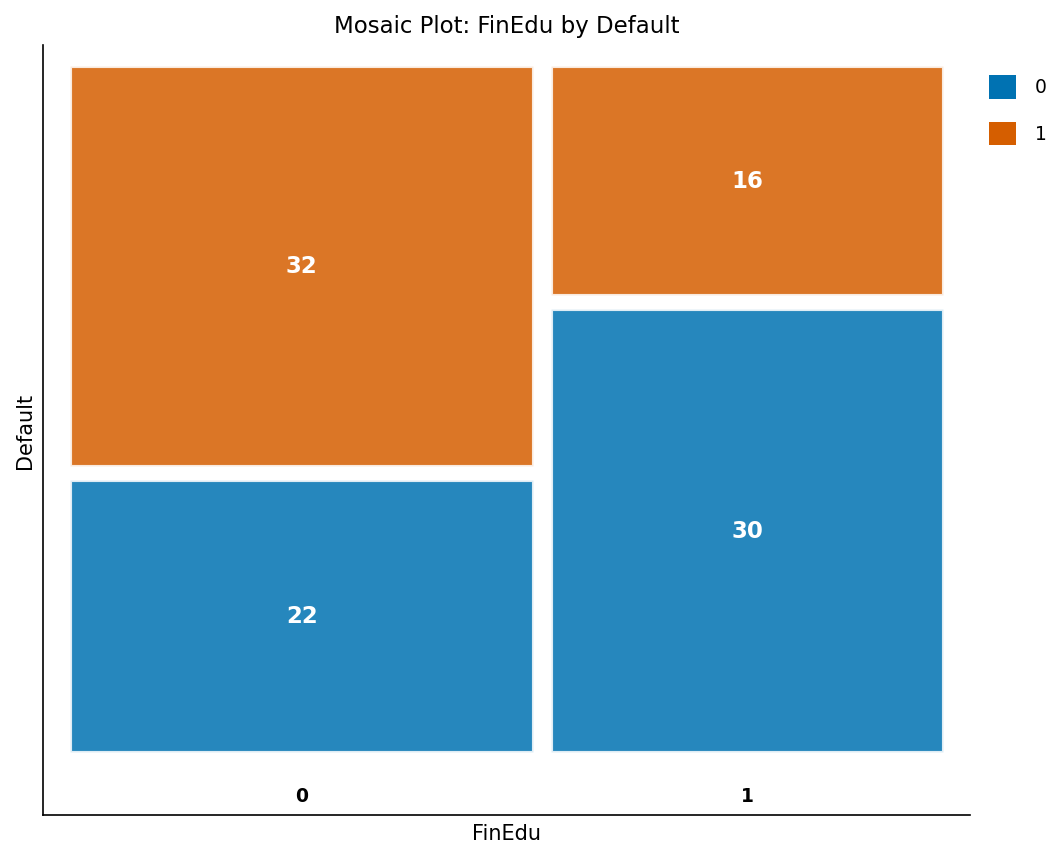

In [3]:
処理 度数 データ=LoanProgram;
   TABLES FinEdu*Default / nocol nopercent;
   label FinEdu='金融教育' Default='債務不履行';
   表題 '金融教育登録と債務不履行のクロス集計';
実行;

非加入の借り手 54 人のうち **32 人がデフォルト** し、加入した 46 人のうちデフォルトしたのはわずか **16 人** でした。モザイクプロットはこれを同時に 2 通りの方法で符号化しています。列の幅は各群に含まれる借り手の人数を反映し、各列内のオレンジ色の割合はデフォルト率です — 右側の加入群では明らかに小さくなっています。媒介分析はここで、その低いデフォルト率のうち **どれだけ** が、先ほど見た高い貯蓄を *通じて* 作用するプログラムによるものかを問います。

## ステップ 3 — 因果媒介分析を実行する

`PROC CAUSALMED` を当てはめます。主なステートメントは次のとおりです。

- **`CLASS FinEdu Default / descending`** は、処置と二値アウトカムを分類変数として宣言します。`DESCENDING` により、コードが高い水準(`1` = 加入 / デフォルト)がモデル化されるイベントになり、効果が直感的な向きで読み取れます。
- **`MEDIATOR SavingsRate = FinEdu`** は媒介モデルを指定します。貯蓄率を処置(および交絡因子)に回帰します。
- **`MODEL Default = FinEdu SavingsRate`** はアウトカムモデルを指定します — 加入と貯蓄の関数としてのデフォルトです。このライセンスなしのエンジンでは、CAUSALMED はアウトカムを **線形(線形確率)モデル** で当てはめるため、効果は **リスク差** スケールで報告され、オッズ比とリスク比の要約が併せて導出されます。
- **`COVAR CreditScore Income Age`** は両方のモデルを処置前の交絡因子で調整します。
- **`DECOMP`** は、総効果を直接成分と間接成分、および媒介割合へと分解することを要求します。

アウトカムが二値であるため、CAUSALMED は *二値アウトカムの要約(Summary for Binary Outcome)* ブロック(オッズ比、リスク比、リスク差)も報告します。

In [4]:
処理 causalmed データ=LoanProgram decomp;
   分類    FinEdu Default / DESCENDING;
   mediator SavingsRate = FinEdu;
   模型    Default = FinEdu SavingsRate;
   covar    CreditScore Income AGE;
   label FinEdu='金融教育' Default='債務不履行' SavingsRate='貯蓄率' CreditScore='信用スコア' Income='所得' AGE='年齢';
   表題 '因果媒介分析：金融教育が債務不履行に与える効果の分解';
実行;

                                                   金融教育登録と債務不履行のクロス集計                                                   


                       The CAUSALMED Procedure                       

Outcome Variable    : 債務不履行
Treatment Variable  : 金融教育
Mediator Variable   : 貯蓄率
Outcome Model Class : Linear (with optional AFT and Cox PH support)
Covariates          : 信用スコア, 所得, 年齢
Number of Observations: 100

Outcome Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                             1.558234
金融教育                                 -0.031682
貯蓄率                                  -0.067687
信用スコア                                -0.000719
所得                                    0.000002
年齢                                   -0.000607

Mediator Model Parameter Estimates
--------------------------------------------
Parameter                       Estimate
Intercept                           -12.585613
金融教育                 


NOTE: PROC CAUSALMED data=LoanProgram



## 結果の解釈

**因果効果の要約(Summary of Causal Effects)** の表は、プログラムの **デフォルトに対する総効果(TE)を -0.208** と報告し、それを次のように分割します。

- **自然直接効果(NDE)-0.032** — 保護のうち貯蓄を *通らない* 部分、そして
- **自然間接効果(NIE)-0.176** — プログラムが借り手の貯蓄率を引き上げることを通じて流れる部分。

3 つの効果はすべて負であり、加入がデフォルト確率を低下させることを裏付けています — これはデータを構築した方法と整合します。2 つのモデル表はその *理由* を示します。**媒介モデル** では、調整後にプログラムが貯蓄率を **+2.60 ポイント** 上昇させ(`FINEDU` の係数)、**アウトカムモデル** では貯蓄が 1 ポイント増えるごとにデフォルト確率が低下します(`SAVINGSRATE` = -0.068)。したがって、プログラムによる貯蓄の押し上げは相当な間接的保護効果へと変換されます。

**効果の分解(Decomposition of Effects)** の表は、主要な知見を明示します。**媒介割合(NIE/TE)は 84.7%** であり、効果のうち直接的な部分はわずか **15.3%** にすぎません。リスクチームにとってこれは行動につながります — 金融リテラシープログラムは **主に貯蓄行動を変えることで** 機能するため、家計管理と自動貯蓄機能の強化を優先すべきです。直接的な割合が控えめであることは、他の経路(関与、連絡の取りやすさ)がここではほとんど寄与しないことを示唆します。

**二値アウトカムの要約(Summary for Binary Outcome)** ブロックは、信用リスクチームが既に使用しているスケールで効果を言い換えます。**リスク差 -0.208**(TE)、**リスク比 1.43**、そして加入群と非加入群のデフォルトオッズを関係づける **オッズ比 2.38** です。このエンジンでは、これらは当てはめられたロジスティックモデルではなく線形確率効果から導かれる一次の要約であるため、**リスク差が主たる正確な効果指標** であり、比の要約はおおよその値として読むのが最適です。

**注意点:** 因果媒介の推定値は、処置–アウトカム関係と媒介変数–アウトカム関係の両方について「未測定の交絡がない」という仮定が信頼できる範囲でしか信頼できません。ここではその仮定は構成上成り立っています(合成データ)。実運用では、リスクチームはこの分解に基づいて行動する前に、銀行の完全な申込者特徴量セットと感度分析を用いてそれを擁護するでしょう。推定値は 100 人の借り手からなる単一の標本を反映しているため、実運用の研究では確固たる結論を導く前に信頼区間(例えば分解のブートストラップによる)を付けることになります。